# 4. pytorch custom datasets

- 이전 과정 : 데이터셋 찾기 -> 데이터셋을 숫자 형태로 변환 -> 그 숫자들 속에서 패턴을 찾아 예측에 사용할 수 있는 모델을 만들거나 기존 모델 사용

# 커스텀 데이터셋이란?
: 현재 내가 해결하려는 특정 문제와 관련된 데이터 모음

# 0 ) pytorch 불러오기 및 device-agnostic  코드 설정

In [1]:
import torch
from torch import nn
torch.__version__

'2.10.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

# 1 ) 데이터 가져오기 

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

data\pizza_steak_sushi directory exists.


# 2 ) 데이터 준비

- 내가 어떤 데이터를 다루고 있는지 아는 것이 매우 중요함
- 이미지 분류 형식 <br>
:  각 클래스의 이미지가 해당 클래스 이름을 가진 별도의 폴더에 저장된 구조

In [4]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


-> 각 학습(train) 클래스마다 약 75장의 이미지가 있고,
각 테스트(test) 클래스마다 약 25장의 이미지가 있음

- 학습 경로(train path)와 테스트 경로(test path) 설정

In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

# 2.1 ) 이미지 시각화

Random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


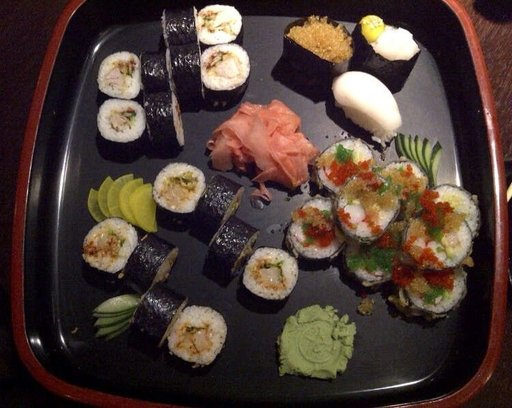

In [7]:
import random
from PIL import Image

random.seed(42)

# 1. .jpg로 끝나는 모든 이미지 파일 경로 가져오기
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. random.choice() 사용해 그 중 하나의 이미지 경로 무작위 선택
random_image_path = random.choice(image_path_list)

# 3. pathlib.Path.parent.stem을 사용해서 해당 이미지의 클래스 이름을 가져옴
image_class = random_image_path.parent.stem

# 4. 이미지 열기
img = Image.open(random_image_path)

# 5. 이미지를 화면에 출력, 해당 이미지의 메타데이터도 함께 출력
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

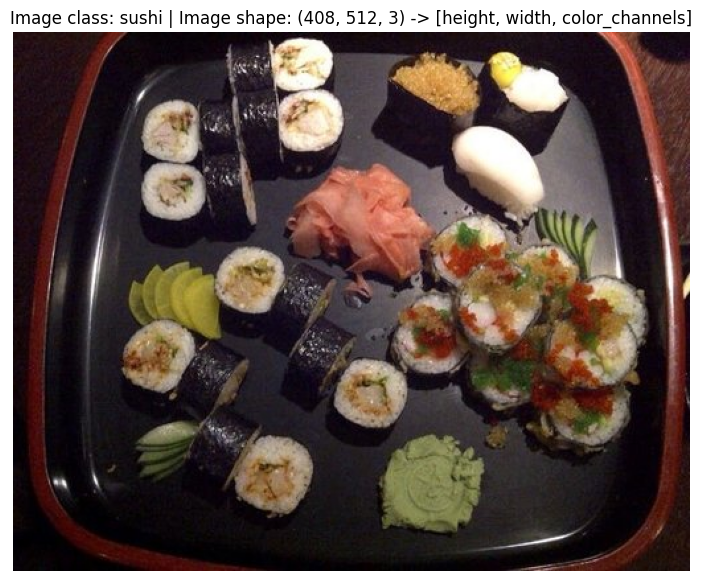

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 이미지 객체(img)를 Numpy 배열로 변환
img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

# 3 ) 데이터 변환 (transforming data)

- pytorch에서 이미지 데이터 사용하기 위해서 거쳐야할 것 <br>
 1. 이미지를 텐서로 변환<br>
 2. 데이터를 torch.utils.data.Dataset 객체로 만들고 torch.utils.data.DataLoader로 감싸기<br>


In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 3.1 ) torchvision.transforms로 데이터 변환

- torchvision.transforms <br>
-이미지를 원하는 형식으로 변환하는 다양한 사전 정의된 함수들 들어있음<br>
-이미지를 텐서로 변환, 데이터 증강(data augmentation)을 위한 조작 가능<br>

- 데이터 변환 단계 작성<br>
1. 이미지 크기 조정 <br>
-transforms.Resize() 사용해 이미지를 512 x 512 크기 -> 64 x 64 크기로 줄임<br>

2. 랜덤 수평 뒤집기<br>
-transforms.RandomHorizontalFlip()을 사용하여 이미지를 무작위로 좌우 반전시킴<br>
-데이터 증강의 한 형태로 원본 이미지를 인위적으롤 변형해 모델이 더 다양한 데이터를 학습하도록 만듬<br>

3. 텐서로 변환<br>
-transforms.ToTensor()를 사용하여 PIL 이미지 → PyTorch 텐서로 변환<br>
-모델은 숫자만 이해할 수 있기 때문<br>

- 위에서 만든 모든 변환 단계를 torchvision.transforms.Compose()를 사용해 하나의 변환 파이프라인으로 묶을 수 있음

In [10]:
# 전처리 공정-원본 이미지를 딥러닝 모델이 학습하기 좋은 형태로 가공
data_transform = transforms.Compose([
    # 모든 이미지 크기를 64x64
    transforms.Resize(size=(64, 64)),
    # 이미지 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # 이미지 텐서로 전환
    transforms.ToTensor() # 원래 이미지 픽셀 값 0~255 사이의 정수를 0.0~0.1 사이 실수 값으로 변환
])

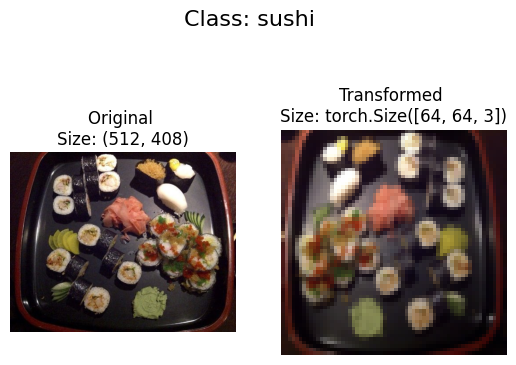

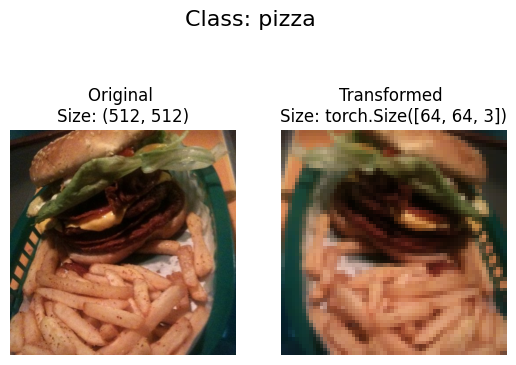

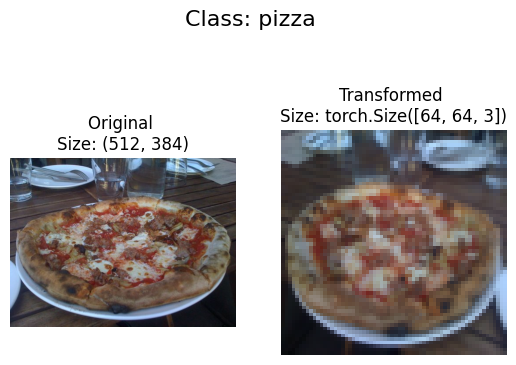

In [11]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    """
    image_paths에서 무작위로 선택된 일련의 이미지들을 시각화
    image_paths에서 n개의 이미지 경로를 열고, 
    그것들을 transform으로 변환한 뒤 그래프 그림
    
    매개변수 (Args) :
        image_paths (list) : 대상 이미지 경로들의 리스트
        transform (Pytorch Transfroms): 이미지에 적용할 전처리(변환) 도구
        n (int, optional): 시각화할 이미지의 개수. 기본값은 3
        seed (int, optional): 무작위 생성을 위한 랜덤 시드 값. 기본값은 42
    """
    
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1,2) # 1행 2열짜리 그래프 생성
            
            #왼쪽 칸(ax[0])에 원본 이미지 그림
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")       # 축 숨기기
            
            # 이미지 변환, Matplotlib 형식에 맞게 차원 바꿈
            transformed_image = transform(f).permute(1, 2, 0)
            # transform(f): 아까 만든 Resize, Flip, ToTensor 공정을 실행합니다. 결과는 PyTorch 텐서 형태인 [색상, 높이, 너비]([C, H, W])
            # .permute(1, 2, 0): 매우 중요합니다. * PyTorch는 색상 채널이 맨 앞에 오지만, 이미지를 화면에 그려주는 Matplotlib은 색상 채널이 맨 뒤에 와야 함.[C, H, W]를 [H, W, C] 순서로 재배치하는 작업
            
            # 오른쪽 칸(ax[1])에 변환된 이미지 그림
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
            
plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)
            
            
            

- 이미지 크기가 클수록 모델이 더 많은 정보 복원(추출) 가능 <br>
[256, 256, 3] 크기의 이미지는 [64, 64, 3] 크기의 이미지보다 16배 더 많은 픽셀을 가집니다 $( (256 \times 256 \times 3) / (64 \times 64 \times 3) = 16 )$

# 4. ImageFolder 사용해 이미지 데이터 불러오기

- torchvision.datasets.ImageFolder 클래스 <br>
-pytorch에서 사용할 수 있는 데이터셋 형태로 변환할 때 이용

*트레이드오프 <br>
고해상도 : 정보량이 많아 성능이 좋아지지만, 메모리 많이 먹고 학습 속도 느려짐<br>
저해상도 : 학습 속도가 빠르고 가볍지만, 너무 작게 줄이면 모델이 중요한 특징 놓칠 수 있음<br>


- ImageFolder 
-데이터가 폴더별로 분류되어 있다면 폴더 이름을 자동으로 클래스 레이블(정답)으로 인식함

4-1. ImageFolder 사용해 실제로 train_data와 test_data 객체 생성하는 코드 작성

In [12]:
#  데이터셋 생성을 위해 ImageFolder 사용
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,       # 이미지들이 들어있는 대상 폴더
                                  transform=data_transform,      # 데이터(이미지)에 적용할 전처리(변환)
                                    target_transform=None)      # 정답(레이블)에 적용할 전처리      
test_data = datasets.ImageFolder(root=test_dir, 
                                 transform=data_transform)
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


4-2. class와 class_to_idx 속성, 그리고 훈련 세트와 테스트 세트와 길이 확인

In [13]:
# 클래스 이름들 리스트로 가져오기
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [14]:
# 클래스 딕셔너리로도 가져올 수 있음
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
# 길이 확인
len(train_data), len(test_data)

(225, 75)

- train_data와 test_data 데이터셋을 인덱싱하여 개별 샘플과 그에 해당하는 타겟 레이블 (데이터의 정답
) 찾기

*인덱싱 : 데이터셋을 리스트처럼 취급해 특정 번호와 데이터를 꺼내오는 것

In [16]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

-> 이미지가 텐서 형태(모양: [3, 64, 64])로 변환되었고, 레이블은 특정 클래스와 연결된 정수 형태(class_to_idx 속성에서 참조됨)가 됨

- matplotlib 사용해서 이미지 텐서 한 장을 화면에 그리기 <br>
- 그 전에 이미지가 호환될 수 있도록 차원 순서 재배치 -> permute 과정 필요 <br>
-우리 이미지의 차원은 CHW(색상 채널, 높이, 너비) 형식이지만, matplotlib은 HWC(높이, 너비, 색상 채널) 형식을 선호하기 때문

기존 shape : torch.Size([3, 64, 64]) -> [color channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


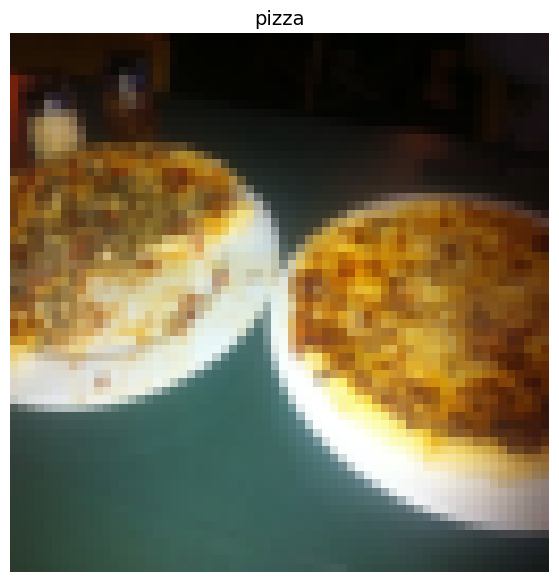

In [17]:
# 차원 순서 재배치
img_permute = img.permute(1, 2, 0)

# 변환 전후의 서로 다른 shape 출력
print(f"기존 shape : {img.shape} -> [color channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# 이미지 시각화 (그래프로 그리기)
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))    # 순서가 바뀐 이미지 전달
plt.axis("off") # 축 표시 끄기
plt.title(class_names[label], fontsize=14); 

# 4.1 ) 로드된 이미지를 DataLoader로 변환하기

- 데이터셋을 DataLoader로 변환 <br>
-데이터가 반복 가능(iterable) 상태가 되어 모델이 샘플(특성)과 타겟(레이블) 사이에 관계를 흝으며 학습할 수 있게 됨 <br>
-torch.utils.data.DataLoader 이용할 것

- 학습을 단순하게 유지하기 위해 batch_size=1과 num_workers=1 사용

*num_workers <br>
: 데이터를 로드하기 위해 생성할 서브 프로세스의 개수 정의 <br>
-num_workers 값을 높게 설정할수록 파이토치가 데이터를 불러오는 데 더 많은 연산 능력 사용

*os.cpu_count() : 컴퓨터의 총 CPU 코어 수 

In [18]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1,
                              shuffle=True) # 데이터 섞기
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False) # 테스트 데이터 순서는 학습에 영향을 주지 않으므로 안섞음

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x22f88bcbc10>,
 <torch.utils.data.dataloader.DataLoader at 0x22f88bcb220>)

In [19]:
img, label = next(iter(train_dataloader))   
# iter(train_dataloader) : DataLoader를 iterable 형태로 만듬
# next(...) : 그중에서 첫 번째 뭉치(Batch)를 실제로 꺼내옴
# img -> 이미지 데이터 묶음, lable -> 그에 대응하는 정답 숫자 묶음이 담김

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


-> dataloader 이후 배치가 추가되어 이미지 모양 변함

-> 이 DataLoader들을 학습 및 테스트 루프에 결합해 모델 훈련시킬 수 있음

- 데이터를 불러올 수 있는 또 다른 방법 알아보기

# 5. Option 2 : 사용자 정의(Custom Dataset) 이용해 이미지 데이터 불러오기

- torchvision.datasets.ImageFolder()와 같이 미리 만들어진 데이터셋 생성기가 없을 때
-> 직접 데이터셋 만들기

- 사용자 정의 데이터셋 <br>
-장점 <br>
1. 거의 모든 데이터를 데이터셋으로 만들 수 있음 <br>
2. pytorch에서 미리 제공하는 함수들에 국한되지 않음 <br>

-단점 <br>
1. 무엇이든 만들 수 있다고 해서 항상 잘 작동하는 것 X<br>
2. 더 많은 코드를 작성해야함. 이는 오류/성능 저하의 원인이 될 수 있음

- 모든 파이토치 데이터셋의 기본 클래스인 torch.utils.data.Dataset을 상속해 ImageFolder 기능 재현하기
-필요한 모듈
1. Python's os : 디렉터리(폴더) 다루기 위해 사용
2. Python's pathlib :  파일 경로 다루기 위해 사용 ( 각 이미지엔 고유한 파일 경로가 있음)   
3. torch : Pytorch의 모든 기능 사용
3. PIL의 Image 클래스 : 이미지 불러오기 위해 사용
4. torchvision.transforms : 이미지를 텐서로 변환하기 위함
5. Python typing module의 다양한 타입들 : 우리 코드에 타입 힌트 제공해 가독성 높임

In [20]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [21]:
# torchvision.datasets.ImageFolder()의 인스턴스(train_data)에서 classes와 class_to_idx 속성 사용하기
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# 5.1 )  클래스 이름을 가져오기 위한 helper 함수 만들기

- 대상 디렉터리 경로가 주어졌을 때, 클래스 이름 리스트와 '클래스 이름-인덱스'쌍으로 이루어진 딕셔너리를 생성할 수 있는 헬퍼 함수 작성
1. os.scandir() 사용해 대상 디렉터리 탐색, 클래스 이름들 가져오기
2. 만약 클래스 이름을 찾을 수 없으면 에러 발생시킴 (이 경우엔 디렉터리 구조에 문제가 있을 것)
3. 클래스 이름들을 각 클래스당 하나씩 숫자 레이블로 매핑된 딕셔너리로 변환

*헬퍼 함수(helper function) <br>
: 복잡한 작업 수행하기 위해 보조적으로 만듬 함수. 여기선 폴더 구조를 분석해 정답지 만드는 역할 함<br>
*표준 이미지 분류 형식 : root/class_name/image.jpg와 같이 폴더 이름 자체가 클래스(정답)가 되는 구조<br>
*대상 디렉터리 경로 (target directort path) : 데이터가 저장되어 있는 폴더의 위치

In [22]:
# 대상 디렉터리를 위한 경로 설정
target_directory = train_dir    # 위에서 정의했던 훈련 데이터 경로를 변수에 할당
print(f"대상 디렉터리: {target_directory}")

# 대상 디렉터리에서 클래스 이름 가져오기
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
# os.scandir: 지정된 경로 내의 파일과 폴더들을 훑어보는 함수
# image_path / "train": 전체 데이터 경로 안의 train 폴더를 가리킴
# [entry.name for entry in ...] (리스트 컴프리헨션) : 폴더 안을 훑으면서 발견된 각 항목(entry)의 이름(name)만 골라내어 새로운 리스트 생성
# sorted() : 추출된 이름들을 알파벳 순서로 정렬. sorted 사용해야 일관된 인덱스 보장 가능
print(f"찾은 클래스 이름: {class_names_found}")

대상 디렉터리: data\pizza_steak_sushi\train
찾은 클래스 이름: ['pizza', 'steak', 'sushi']


*리스트 컴프리헨션 : 리스트를 짧게 한 줄로 만들 수 있는 파이썬의 문법

In [23]:
# 대상 디렉터리에서 클래스들 찾기 위한 함수 정의
def find_classes(directory:str) -> Tuple[List[str], Dict[str, int]]:        
    # 입력: directory (문자열 형태의 폴더 경로)
    # 출력: Tuple [클래스 이름 리스트, 이름과 숫자가 매칭된 딕셔너리(예: {'pizza': 0, 'steak': 1} ]

    # 1. 대상 디렉토리를 스캔해 클래스 이름들 가져오기
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
     # os.scandir로 폴더 내부를 흝으며, 파일이 아닌 디렉토리(is_dir)인 경우만 골라 이름 정렬
     # is_dir() : 디렉터리(폴더)인지 물어보는 함수
     
    # 2. 클래스 이름을 찾지 못했을 경우 에러 발생- 리스트가 비어있다면 경로가 잘못되었거나 폴더 구조가 틀린 것이므로 에러 
    if not classes:
        raise FileNotFoundError(f"{directory}에서 아무 클래스도 찾을 수 없음")
    
    # 3. 인덱스 레이블 딕셔너리 생성 (컴퓨터는 문자열보다 숫자 레이블 선호)
    class_to_idx = {cls_name : i for i, cls_name in enumerate(classes)}
    # 1) enumerate(classes) : classes 리스트를 돌면서 (번호, 클래스명)쌍 생성
    # 2) {cls_name: i for i, cls_name in ...}
    #       for i, cls_name in ... : 위에서 만든 쌍을 하나씩 가져와 번호는 i, 이름은 cls_name에 담음
    #       cls_name:i  :  가져온 이름과 번호를 딕셔너리 형태로 저장
    
    
    return classes, class_to_idx

*함수 정의 시 사용하는 -> 기호 <br>
: 함수가 실행 마친 뒤에 최종적으로 돌려주는 데이터의 형태를 미리 명시 <br>
-강제성 x, 가독성을 위함

- 함수 작성해두었으니 data_loader.py 같은 .py 파일로 옮겨 다른 데이터 관련 함수와 보관하고 재사용 가능
- 이미지 준비하기 위한 변환 과정 만들기

In [24]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# 5.2 ) ImageFolder를 재현하기 위한 사용자 정의 데이터셋 만들기
- torch.vision.datasets.ImageFolder() 기능을 그대로 재현하는 데이터셋 구축

1. torch.utils.data.Dataset 상속
2. targ.dir(대상 데이터 디렉터리)파라미터와 transform(필요한 경우 데이터를 변환할 수 있는 옵션) 파라미터로 서브클래스 초기화(__init__)
3. paths(대상 이미지들의 경로 리스트), transform(사용할 변환 도구,None일 수 있음), 우리가 만든 find_classes( ) 함수 이용해 classes와 classes_to_idx 속성 생성
4. 파일에서 이미지 불러와 반환하는 함수 생성. 이때 PIL이나 torchvision.io 사용 가능
5. torch.utils.data.Dataset의 __len__ 메서드를 재정의(override)하여 데이터셋의 전체 샘플 개수를 반환하게 함. 필수는 아니지만 권장됨. 이렇게 하면 len(Dataset)을 호출 가능함
6. torch.utils.data.Dataset의 __getitem__ 메서드를 오버라이드하여 데이터셋에서 단일 샘플을 반환하도록 함. 이는 필수 사항임

*__getitem__ <br>
>
:데이터셋의 특정 인덱스(i번째) 데이터를 요청했을 때, "이미지를 읽어서 텐서로 바꾸고 정답 번호와 함께 돌려줘"라고 지시하는 핵심 엔진

In [25]:
# 사용자 정의 데이터셋 클래스 작성 (torch.utils.Dataset을 상속받음)
from torch.utils.data import Dataset

# 1. torch.utils.data.Dataset의 자식 클래스(Subclass) 생성
class ImageFolderCustom(Dataset):
    
    # 2. 대상 디렉토리(targ_dir)와 변환 도구(transform, 선택사항) 파라미터로 초기화
    def __init__(self, targ_dir:str, transform=None) -> None:
        
        # 3. 클래스 속성 생성
        # 모든 이미지 경로 가져옴-pathlib를 사용해 해당 폴더 내의 모든 .jpg 파일 경로를 리스트로 만듬
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        # pathlib.Path(targ_dir): 입력받은 폴더 경로 문자열(targ_dir)을 경로 객체로 변환해 폴더 주소인 것을 인식하도록 함
        # .glob(): 파일 시스템에서 특정한 패턴을 가진 파일이나 폴더들을 한꺼번에 찾아내는 함수
        
        self.transform = transform      # 변환 도구 설정
        self.classes, self.class_to_idx = find_classes(targ_dir)    # 앞서 만든 find_classes 함수를 사용하여 정답지 정보 가져옴
        
    # 4. 이미지를 불러오는 함수     
    def load_image(self, index : int) -> Image.Image : 
        "경로를 통해 이미지를 열고 반환"
        image_path = self.paths[index]  # 인덱스에 해당하는 이미지 경로 추출
        return Image.open(image_path)   # PIL을 사용해 이미지 파일 열기
    
    # 5. __len__() 메서드 오버라이드 (Dataset의 하위 클래스에서 필수)
    def __len__(self) -> int:
        "전체 샘플 수 반환"
        return len(self.paths) # 이미지 경로 리스트의 길이 반환
    
    #  6. __getitem__() 메서드 오버라이드
    def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:
        "데이터 한 샘플을 반환함, 데이터와 레이블 (X, y)."
        img = self.load_image(index)    # 위에서 만든 함수로 이미지 로드
        
        # 부모 폴더의 이름을 클래스 이름으로 가져옴 (데이터폴더/클래스이름/이미지.jpg 구조 가정)
        class_name = self.paths[index].parent.name
        
        # 클래스 이름을 숫자로 변환-정답 번호 추출
        class_idx = self.class_to_idx[class_name]
        
        # 필요하다면 변환 적용
        if self.transform:
            # 이미지에 변환을 적용한 뒤 (데이터, 레이블) 쌍으로 반환
            return self.transform(img), class_idx
        else:
            # 변환 없이 원본 이미지와 레이블 반환
            return img, class_idx

- 변환(transforms) 과정 만들기

*data augmentation : 데이터 증강

In [26]:
# 1. 훈련 데이터 전처리 : 더 어렵고 다양한 학습 (Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),     # 모든 이미지 크기 통일
    transforms.RandomHorizontalFlip(p=0.5),     # 50% 확률로 좌우 반전시켜 데이터 양 늘림
    transforms.ToTensor()       # 이미지를 0~1 사이의 숫자로 바꾸고 텐서 형식으로 변환
])

# 2. 테스트 데이터 전처리 - no Augmentation
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),        # 훈련 데이터랑 동일한 크기로 통일
    transforms.ToTensor()               # 모델이 읽을 수 있게 텐서 형식으로만 변환
])

- 우리의 훈련용 이미지 & 테스트용 이미지를 직접 만든 ImageFolderCustom 클래스 이용해 Dataset 객체로 변환하기

In [27]:
train_data_custom = ImageFolderCustom(targ_dir = train_dir,     # __init__  함수에 있는 targ_dir 매개변수에 train_dir 전달
                                      transform=train_transforms)   # 전처리 도구 세트 전달 
test_data_custom = ImageFolderCustom(targ_dir = test_dir,       # 
                                     transform=test_transforms)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x22f88bde350>,
 <__main__.ImageFolderCustom at 0x22f88bdf040>)

새로 만든 데이터셋에 len()을 호출해보고, classes와 class_to_idx 속성들을 확인

In [28]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [29]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [30]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

직접 만든 엔진(ImageFolderCustom)이 Pytorch가 공식적으로 제공하는 엔진(ImageFolder)과 똑같이 동작하는지 검증

*공식 라이브러리인 ImageFolder는 매우 편리하지만, 때로는 우리가 특별한 형태의 데이터(예: 텍스트 파일과 이미지가 섞인 경우, 혹은 특정 조건의 파일만 걸러내야 하는 경우)를 다뤄야 할 때가 있음

이때 우리가 직접 만든 ImageFolderCustom이 공식 라이브러리와 똑같은 결과를 낸다는 것을 확인했다면, 이제 "기본 기능은 유지하면서 나만의 특별한 로직을 추가할 수 있음"을 확인함

- 우리가 직접 만든 클래스와 torchvision.datasets.ImageFolder() 클래스로 만든 데이터셋이 서로 일치하는지 확인

In [31]:
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


# 5.3 ) 무작위 이미지를 표시하는 함수 만들기

- displat_random_images() : Dataset에 있는 이미지들을 시각화해 주는 도우미 함수

1. Dataset 객체와 classes(타겟 클래스 이름들), 표시할 이미지 수(n), 그리고 랜덤 시드(seed) 같은 파라미터들을 입력받음

2. 디스플레이가 너무 커져서 감당 안 되는 걸 방지하기 위해, n의 최댓값을 10개로 제한함

3. 랜덤 시드 설정

4. 출력할 무작위 샘플 인덱스 리스트를 가져옴(파이썬의 random.sample()을 사용)

5. matplotlib 그래프 설정

6. 4단계에서 찾은 무작위 인덱스들을 반복문으로 돌리며 matplotlib으로 그림을 그림

7. 샘플 이미지가 출력 가능한 HWC (세로, 가로, 색상 채널) 형태인지 확인




In [32]:
import torch
import random
import matplotlib.pyplot as plt
from typing import List

# 1. 데이터셋 클래스 이름 리스트를 입력받는 함수
def display_random_images(dataset: torch.utils.data.dataset.Dataset,       # 커스텀 데이터셋
                          classes : List[str] = None,                           # 클래스 이름 리스트
                          n: int = 10,                                          # 보여줄 이미지 개수
                          display_shape: bool = True,                           # 이미지 크기 표시 여부
                          seed: int = None):                                    # 랜덤 결과 고정용 시드
    
    # 2. n의 최대값 10개로 제한
    if n > 10:
        n = 10
        display_shape = False       # 10개가 넘어가면 글자가 겹칠 수 있어 크기 표시 끔
        print(f"시각화를 위해 n을 10으로 설정, 이미지 크기 표시를 비활성화")
        
    #  3. 랜덤 시드 설정 - 항상 똑같은 사진 보고 싶을 때 사용
    if seed :
        random.seed(seed)
        
    # 4. 전체 데이터셋 인덱스 중 중복 없이 n개를 무작위로 선택
    # range(len(dataset))은 0부터 끝까지의 번호표 뭉치
    random_samples_idx = random.sample(range(len(dataset)), k=n)
    
    # 5. 그래프를 그릴 도화지 설정
    plt.figure(figsize=(16, 8))
    
    # 6. 선택된 무작위 번호들을 하나씩 돌면서 이미지 출력
    for i, targ_sample in enumerate(random_samples_idx):
        # 데이터셋의 __getitem__을 실행해 이미지와 라벨 가져옴
        target_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
        
        # 7. 파이토치 텐서의 차원 순서 변경 - maplotlib에서 읽을 수 있는 순서로
        # [C, H, W] -> [H, W, C]
        targ_image_adjust = target_image.permute(1, 2, 0)       # permute(dims) : 텐서의 차원 순서 변경
        
        # 8. 한 줄에 n개의 칸을 만들고 i+1번째 칸에 그림을 그림
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)   # 가공된 이미지 출력
        plt.axis("off")      # 이미지 옆의 숫자 축(0~64)을 숨김
        
        # 9. 클래스 이름과 이미지 크기를 제목으로 표시
        if classes:
            title = f"class: {classes[targ_label]}" # 숫자 정답을 글자 정답으로 변환
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"       # 크기 정보 추가
                
        plt.title(title)         

- 우리가 torchvision.datasets.ImageFolder()로 만든 데이터셋을 사용해서 먼저 테스트해보기

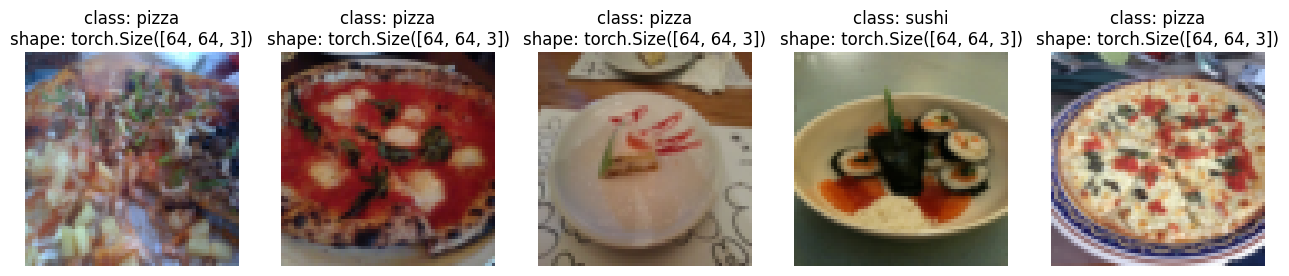

In [33]:
# ImageFolder가 만든 Dataset에서 랜덤 이미지 시각화
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

시각화를 위해 n을 10으로 설정, 이미지 크기 표시를 비활성화


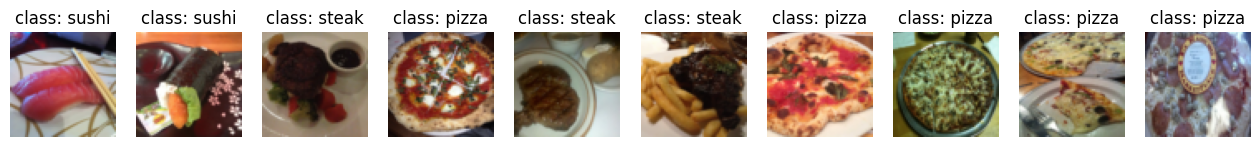

In [34]:
# ImageFolderCustom 데이터셋에서의 랜덤 이미지 시각화
display_random_images(train_data_custom,
                      n=12,
                      classes=class_names,
                      seed=None)

# 5.4 ) 사용자 정의 이미지를 DataLoader로 변환
- 배운 것 : ImageFolderCustom 클래스를 통해 원본 이미지를 Dataset (특징 x와 라벨y가 매핑된 형태)으로 변환하는 법<br>
-특징(features)-모델이 보고 공부하는 데이터.이미지 그 자체 | 라벨(Labels)-모델이 맞춰야 할 정답 <br>
- Dataset을 DataLoader로 변환 -> torch.utils.data.DataLoader() 사용 <br>
-우리가 만든 커스텀 Dataset은 torch.utils.data.Dataset을 상속받음 -> torch.utils.data.DataLoader()에 그대로 넣어서 사용 가능<br>
-직접 만든 Dataset 객체 사용하기

*Dataset : 책장에 꽂힌 책들 <br>
DataLoader : 그 책들을 한 번에 읽을 수 있는 분량(Batch)만큼 꺼내주는 사서    <br>

In [35]:
# 학습&테스트 커스텀 데이터셋들을 DataLoader로 변환
from torch.utils.data import DataLoader
train_dataloader_custom =  DataLoader(dataset=train_data_custom,    # 커스텀 훈련 데이터셋 사용
                                      batch_size=1,                 # 한 번에 모델에게 전달할 데이터 개수
                                      num_workers=0,                 # 데이터를 불러올 때 사용하는 CPU 개수. 0은 메인 프로세스만 사용한다는 뜻
                                      shuffle=True)
# 2. 테스트용 커스텀 데이터셋을 데이터로더로 변환
test_dataloader_custom = DataLoader(
    dataset=test_data_custom,  # 우리가 직접 만든 테스트 데이터셋을 사용합니다.
    batch_size=1, 
    num_workers=0, 
    shuffle=False              # 테스트 시에는 보통 데이터를 섞을 필요가 없습니다. 
                               # 일정한 순서로 평가해야 결과를 확인하기 좋기 때문입니다.
)

In [36]:
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x22f88f3d150>,
 <torch.utils.data.dataloader.DataLoader at 0x22f88f3d750>)

In [37]:
# 커스텀 데이터로더에서의 이미지와 라벨 가져오기
img_custom, label_custom = next(iter(train_dataloader_custom))
# iter(train_dataloader_custom) : 데이터로더를 반복가능한 객체로 변환
# next(): 준비된 데이터더미에서 첫 번째 뭉텅이 끄집어냄

print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}") # 정답 개수

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


# 6 ) 다른 형태의 변환 (데이터 증강, Data Augmentation)

- 변환의 목적 : 이미지를 변경하는 것 <br>


(1) 데이터 증강 <br>
: 데이터를 인위적으로 변경해 훈련 세트의 다양성 높임 <br>
목적-인위적으로 변경된 데이터셋으로 모델을 훈련시키면, 모델이 더 나은 일반화(Generalization) 능력을 가짐. 즉, 학습할 때 본 적 없는 새로운 데이터(미래의 예시들)에 대해서도 더 강력하고 유연한 패턴을 학습하게 됨 <br>

(2) TrivalAugment : 무작위의 힘 <br>
-사람이 직접 고른 변환보다 transforms.RandAugment()나 transforms.TrivialAugmentWide() 같은 무작위 변환이 일반적으로 더 좋은 성능을 냄 <br>
-방식<br>
1.사용 가능한 여러 변환 도구 세트를 준비<br>
2.그중 몇 개를 무작위로 뽑아서 이미지에 적용<br>
3.변환의 강도(Magnitude) 또한 정해진 범위 내에서 무작위로 결정(강도가 높을수록 더 강하게 변형됨)<br>

transforms.TrivialAugmentWide()를 사용할 때 가장 눈여겨봐야 할 설정값은 num_magnitude_bins=31 <br>
*num_magnitude_bins=31 <br>
변형의 강도 범위 설정 : 0 ~ 31

In [38]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()  # 모든 수치를 0과 1 사이로 맞추기 위해 마지막에 ToTensor()를 사용 - 0~1 사이의 작은 숫자로 넣어줘야 모델이 훨씬 더 빠르고 안정적으로 학습
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

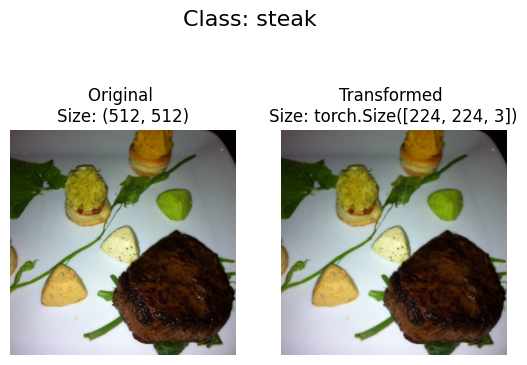

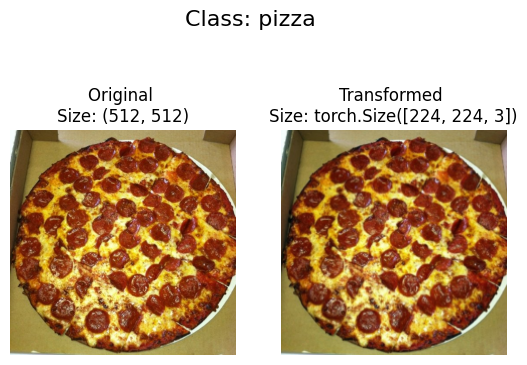

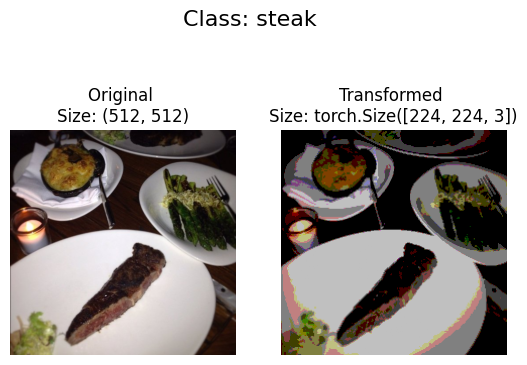

In [39]:
# 데이터 증강 확인
image_path_list = list(image_path.glob("*/*/*.jpg"))

plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
    
)

# 7 ) 모델 0 : 데이터 증강이 없는 TinyVGG
- 기본적인 변환(단순히 이미지 크기를 **(64, 64)**로 조절하고 텐서로 바꾸는 작업)만 적용해보기

# 7. 1 ) 모델 0을 위한 변환 생성 및 데이터 로드
- 가장 단순한 형태의 모델(Baseline)을 먼저 만들기

In [40]:
# 간단한 변환 생성
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

1. 데이터 불러오기 <br>
우선 torchvision.datasets.ImageFolder()를 사용하여 훈련(train) 및 테스트(test) 폴더를 각각 Dataset으로 변환
2. 데이터 로더 만들기 <br>
그다음 torch.utils.data.DataLoader()를 사용하여 이 데이터셋들을 DataLoader로 변환합니다. 이때 batch_size=32로 설정하고, num_workers는 현재 사용 중인 기기의 CPU 코어 개수만큼 설정(이 값은 사용 환경에 따라 달라짐)

In [41]:
# 1. 데이터 로드하고 변환
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. 데이터를 데이터로더로 변환
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()        #os.cpu_count(): 현재 컴퓨터의 CPU 코어 개수를 자동으로 찾아냄
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

train_dataloader_simple = DataLoader(train_data_simple, 
                                     batch_size=BATCH_SIZE, 
                                     shuffle=True, 
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 40 workers.


(<torch.utils.data.dataloader.DataLoader at 0x22f890b1450>,
 <torch.utils.data.dataloader.DataLoader at 0x22f88bdefb0>)

# 7.2 ) TinyVGG 모델 클래스 생성

In [42]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape :int, hidden_units: int, output_shape: int ) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,      # 2차원 합성곱 연산 수행하는 함수 -> 패턴 찾기
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,     # 이미지 흝는 속도/간격. 한번에 몇 칸씩 건너뛸 것인지
                      padding=1),
            nn.ReLU(),      # 비선형 활성화 함수
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,     # 이미지 크기를 절반으로 줄이면서 가장 강한 특징만 남깁니다. (압축)
                         stride=2) # stride값이 kernalsize와 같은 것이 기본값
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(        # 분류기
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)        #  64x64 이미지가 MaxPool2d를 두 번 거치면 64 -> 32 -> 16으로 크기가 줄어듬. 그래서 마지막 Linear 층에 들어올 때 데이터는 hidden_units(채널 수) x 16 x 16 크기가 되어 있는 것
        )
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print (x.shape)
        x = self.conv_block_2(x)
        # print (x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x 
        # return self.classifier(self.conv.block_2(self.conv_block(x)))     # <- 이렇게 한 줄 문법 가능 ( 연산자 융합)
            
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # 컬러 채널 개수 (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

*GPU에서 딥러닝 모델의 계산 속도를 높이는 방법 중 하나는 연산자 융합(operator fusion)을 활용하는 것 <br>
-> 이렇게 하면 x를 다시 할당하는 데 드는 시간(메모리 부하가 큼)을 절약하고, 오직 x에 대한 계산에만 집중할 수 있

# 7.3 ) 단일 이미지로 순전파(Forward Pass) 시도 (모델 테스트)

- 모델을 테스트하는 가장 좋은 방법 중 하나는 단 한 개의 데이터만 넣어 순전파를 실행해 보는 것 <br>
-> 모델의 각 층(layer)에서 입력과 출력의 형태(Shape)가 우리가 의도한 형태인지 확인하는 아주 유용한 방법

- 단일 이미지에 대해 순전파를 수행하기 위한 단계
1. 데이터 로더(DataLoader)에서 이미지와 라벨 한 배치를 가져옵니다.

2. 배치에서 단일 이미지 하나를 꺼낸 뒤, 모델의 입력 규격에 맞게 배치 크기가 1이 되도록 unsqueeze()를 사용하여 차원을 늘려줍니다.

3. 단일 이미지에 대해 추론(Inference)을 수행 (이때 이미지를 반드시 대상 장치인 device로 보내야 합니다).

4. 진행 과정을 출력하고, 모델의 가공되지 않은 출력값인 로짓(Logits)을 torch.softmax()를 사용하여 예측 확률(Prediction Probabilities)로 변환합니다 (다중 클래스 데이터를 다루고 있기 때문입니다). 마지막으로 torch.argmax()를 사용하여 예측 확률을 최종 예측 라벨(Prediction Labels)로 변환


In [43]:
# 1. DataLoader에서 배치만큼의 이미지와 라벨들 가져오기
img_batch, label_batch = next(iter(train_dataloader_simple)) 

# iter() (Iterator): 데이터 묶음(리스트, 데이터로더 등)에 "자, 이제 하나씩 꺼낼 준비 해!"라고 말하는 것
# next(): 그 화살표가 가리키는 데이터를 하나 꺼내고, 화살표를 다음으로 옮김


# 2. 단일 이미지 추출 및 차원 맞추기 (unsqueeze)
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]

# dim=0 :  맨 앞(0번 위치)에 차원을 하나 추가
# unsqueeze : 크기가 1인 차원을 특정 위치에 새로 끼워 넣는 것

print(f"Single image shape: {img_single.shape}\n")

# 3. 단일 이미지에 순전파 수행
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))
    
# 4. 모델의 출력 변환 logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"실제 정답:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0578, 0.0634, 0.0351]], device='cuda:0')

Output prediction probabilities:
tensor([[0.3352, 0.3371, 0.3277]], device='cuda:0')

Output prediction label:
tensor([1], device='cuda:0')

실제 정답:
2


# 7.4 )  torchinfo를 사용해 모델을 통과하는 데이터의 형태(shape) 파악

torchinfo 라이브러리 : summary() 메서드를 제공하는데, 이 메서드에 파이토치 모델과 input_shape를 전달하면 텐서가 모델을 통과할 때 어떤 변화가 일어나는지 한눈에 보여줌

In [57]:
try:
    import torchinfo
except:
    import torchinfo
    
from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

total params :  모델 전체 파라미터 개수 <br>
estimated total size :  모델의 용량

# 7.5 ) 훈련 및 테스트 루프 함수 만들기

- 함수화(functionize)
1. train_step(): 모델, DataLoader, 손실 함수(loss function), 옵티마이저(optimizer)를 입력받아 데이터를 학습시킵니다.

2. test_step(): 모델, DataLoader, 손실 함수를 입력받아 모델의 성능을 평가합니다.

3. train(): 설정한 에포크(epochs) 횟수만큼 1번과 2번 과정을 함께 수행하고, 결과값이 담긴 딕셔너리를 반환합니다.

- train_step() 만들기 시작
DataLoader를 통해 배치(batch) 단위로 데이터를 처리하기 때문에, <br>
훈련하는 동안 모델의 손실(loss) 값과 정확도(accuracy) 값을 (각 배치마다 더해서) 누적 -> 그리고 함수를 마치기 직전에 최종적으로 값을 조정(평균화)하여 반환

In [45]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    model.train()
    
    train_loss, train_acc = 0,0
    
    
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. 손실 계산과 누적
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # 모든 배치(Batch)에 대해 정확도 지표(Accuracy metrics)를 계산하고 누적
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # 배치당 평균 손실(loss)과 정확도(accuracy)를 구하기 위해 지표를 조정
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [52]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss 
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

* context manager : 파이썬에서 with 키워드와 함께 사용하는 것을 말합니다. with 블록 안에 있는 동안만 특수한 환경(컨텍스트)이 유지된다는 뜻

# 7.6 ) train_step()과 test_step()을 결합한 train() 함수 만들기
- 두 함수를 패키징하여 하나의 train() 함수로 묶을 것

1. 모델, 훈련 및 테스트용 데이터 로더(DataLoader), 옵티마이저(optimizer), 손실 함수(loss function), 그리고 몇 번의 에포크(epochs)를 반복할지를 입력받습니다.

2. train_loss, train_acc, test_loss, test_acc 값을 저장할 빈 결과 딕셔너리(results dictionary)를 만듭니다 (학습이 진행됨에 따라 이 딕셔너리를 채워 나갑니다).

3. 설정된 에포크 횟수만큼 훈련 및 테스트 단계 함수를 반복해서 실행합니다.

4. 매 에포크가 끝날 때마다 진행 상황(점수)을 출력합니다.

5. 매 에포크의 최신 지표로 결과 딕셔너리를 업데이트합니다.

6. 최종적으로 모든 수치가 채워진 딕셔너리를 반환합니다.

*학습이 몇 번째 에포크까지 진행되었는지 추적하기 위해 tqdm.auto에서 tqdm을 가져와 사용
-tqdm은 파이썬에서 가장 인기 있는 상태 표시줄(Progress bar) 라이브러리

In [48]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),     # 손실 함수 : 모델의 예측값과 실제 정답 사이의 거리를 계산
          epochs: int = 5):
    
    # 빈 결과 딕셔너리 생성
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    for epoch in tqdm(range(epochs)):           # range(epochs): 만약 epochs=5라면 [0, 1, 2, 3, 4]라는 숫자 리스트를 만듭니다. 즉, 전체 과정을 5번 반복하겠다는 뜻
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results


- train_step(...) : 실전 같은 연습 (공부 단계) <br>
루프가 한 번 돌 때마다(매 에포크마다) 가장 먼저 실행됩니다.<br>
역할: 훈련 데이터(train_dataloader)를 모델에게 줍니다.<br>
내부 동작:<br>
1. 모델이 예측값을 내놓습니다.<br>
2. loss_fn으로 얼마나 틀렸는지 계산합니다.<br>
3. 옵티마이저를 사용해 모델의 가중치(Weights)를 수정합니다. (실제로 똑똑해지는 과정)<br>
결과: 이번 판의 평균 손실(train_loss)과 정확도(train_acc)를 가지고 돌아옵니다.<br>

# 7.7 ) 모델 0 학습 및 평가

- 완전성을 기하기 위해 model_0를 다시 생성한 다음(필수는 아니지만 정리 차원에서 진행합니다), 필요한 매개변수들을 전달하여 train() 함수를 호출
- 실험을 빠르게 진행하기 위해 5 에포크(5 epochs) 동안 학습
- 손실 함수(Loss function)와 옵티마이저(Optimizer)의 경우, <br>
다중 클래스 분류 문제를 다루고 있으므로 torch.nn.CrossEntropyLoss()를 사용하고, torch.optim.Adam()(학습률 1e-3)을 각각 사용
- 학습에 시간이 얼마나 걸리는지 확인하기 위해 파이썬의 timeit.default_timer() 메서드를 임포트하여 전체 학습 시간을 계산

*TinyVGG : 작고 효율적인 합성곱 신경망(CNN)

In [ ]:
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# 타이머 시작
from timeit import default_timer as timer 
start_time = timer()

# modl_0 학습
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# 타이머 끄고 시간 측정
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1623 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1155 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0986 | train_acc: 0.4141 | test_loss: 1.1344 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0987 | train_acc: 0.2930 | test_loss: 1.1433 | test_acc: 0.1979
Total training time: 109.399 seconds


*SGD (경사하강법): 일정한 속도로 산을 내려가는 방식 <br>
Adam: 가파른 곳은 빠르게, 평탄한 곳은 신중하게 내려가는 '똑똑한 등산객' 같은 방식 <br>

*optimizer : 인공지능/딥러닝 모델 학습 시, 손실 함수(Loss Function)의 값을 최소화하도록 모델의 가중치(Weight)와 편향(Bias)을 업데이트하는 알고리즘

# 7.8 모델 0의 손실 곡선(Loss Curves) 시각화

- 손실 곡선
: 시간이 흐름(에포크)에 따라 모델의 결과가 어떻게 변하는지 보여줍 <br>
-손실 곡선(Loss curves)을 그려보면 모델의 상태를 훨씬 더 깊이 있게 평가할 수 있음 <br>
-훈련 데이터와 테스트 데이터라는 서로 다른 데이터셋에서 모델이 어떻게 작동하는지 비교해 볼 수 있는 아주 좋은 방법 <br>

- model_0_results 딕셔너리에 저장된 값들을 그래프로 그려주는 함수 만들기

In [54]:
# model_0의 결과 키들 확인
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

- 각각의 키 추출해 그래프로 만들기

In [55]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
    """결과 딕셔너리로부터 학습 곡선을 그림
    
    Args:
        results (dict): 다음과 같이 리스트를 값으로 가진 딕셔너리:
            {"train_loss": [...], 
             "train_acc": [...], 
             "test_loss": [...], 
             "test_acc": [...]}
    """
    # 결과 딕셔너리에서 손실(loss) 값 추출 (훈련 및 테스트)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # 결과 딕셔너리에서 정확도(accuracy) 값 추출 (훈련 및 테스트)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    
    epochs = range(len(results['train_loss']))  # 에포크가 몇 번 진행되었는지 계산
    
    plt.figure(figsize=(15, 7))     #  그래프 설정을 위한 Figure 생성
    
    # 손실(Loss) 그래프 그리기 (왼쪽)
    plt.subplot(1, 2, 1)        # 가로 1칸, 세로 2칸짜리 격자에서 1번째 칸을 쓰겠다
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()        # 각 선이 무엇을 의미하는지 설명해주는 범례(네모칸 설명)를 화면에 표시

    # 정확도(Accuracy) 그래프 그리기 (오른쪽)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

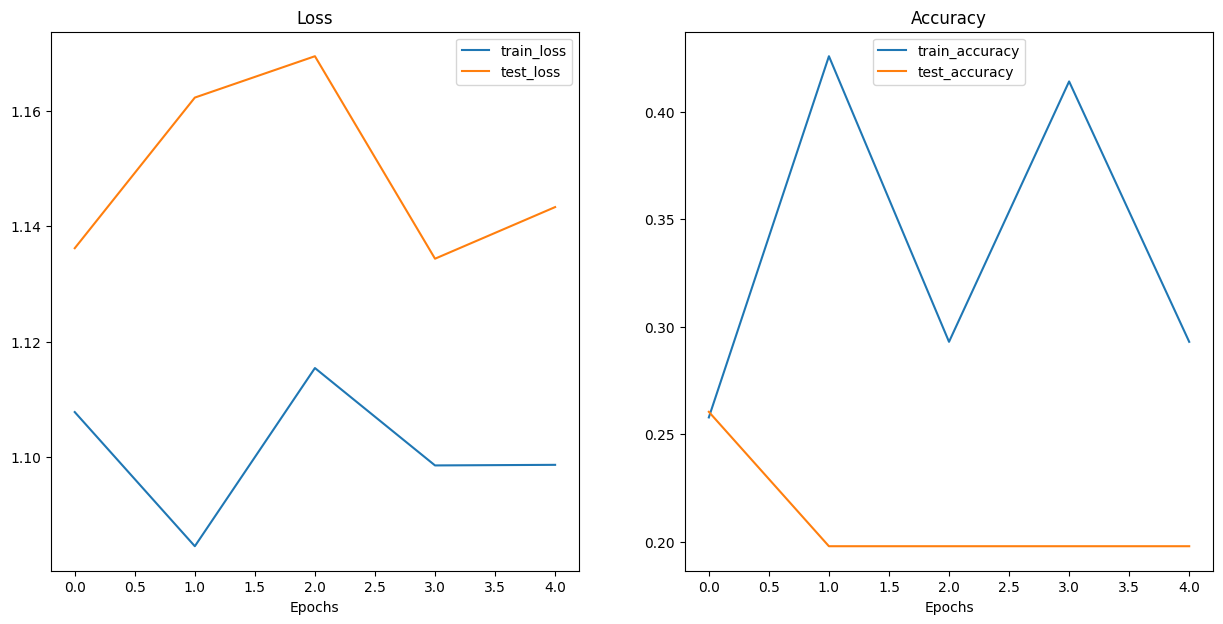

In [56]:
plot_loss_curves(model_0_results)

#  8 ) 이상적인 손실 곡선(Loss Curve)이란 어떤 모습일까?

훈련 손실 곡선과 테스트 손실 곡선을 관찰하는 것은 모델이 과적합(Overfitting)되고 있는지 확인할 수 있는 아주 좋은 방법<br>

- 과적합(Overfitting)<br>
: 모델이 훈련 데이터셋에서는 (종종 큰 차이로) 아주 잘 작동하지만, 검증/테스트 데이터셋에서는 그렇지 못한 상태 <br>
모델이 훈련 데이터의 패턴을 너무 완벽하게 외워버려서, 새로운 테스트 데이터에는 그 패턴이 적용(일반화)되지 않는 상태

- 과소적합(Underfitting) <br>
: 반대로 훈련 손실과 테스트 손실이 모두 우리가 원하는 만큼 낮아지지 않는 상태

훈련 손실 곡선과 테스트 손실 곡선의 가장 이상적인 모습 -> 두 곡선이 서로 아주 가깝게 나란히 내려가는 것. 두 선 사이의 간격이 좁음

# 8.1 ) 과적합(Overfitting)을 해결하는 방법 <br>
과적합의 주요 문제- 모델이 훈련 데이터에 너무 완벽하게 맞춰져 있다는 것 <br>
-> 이를 억제(reign it in)할 수 있는 기법이 필요<br>

과적합을 방지하는 가장 일반적인 기법-규제(Regularization)<br>
--> 더 다양한 종류의 데이터에 적응할 수 있게 만드는 것<br>

1. 데이터 더 많이 확보
2. 모델 단순화 - 레이어 수나 히든 유닛(은닉 유닛) 수를 줄여서 데이터의 노이즈까지 외우지 못하게 함
3. 데이터 증강 (Augmentation) - 데이터를 인위적으로 변형시켜 모델이 학습하기 까다롭게 만듬
4. 전이 학습 (Transfer Learning) - 이미 대량의 데이터로 학습된 모델의 가중치를 가져와 내 문제에 맞춰 미세 조정(Tuning)
5. 드롭아웃 (Dropout) - 신경망의 연결을 무작위로 끊어 모델을 단순화하고 나머지 연결들이 더 강해지게 만듬
6. 학습률 감쇠 (LR Decay) - 학습이 진행될수록 학습률을 줄임. 소파 틈새의 동전을 집을 때 가까워질수록 손을 조심스럽게 움직이는 것과 같음
7. 조기 종료 (Early Stopping) - 오버피팅이 시작되기 전(예: 10 에포크 동안 성적이 안 오를 때)에 학습을 멈춤




# 8.2 ) 과소적합(Underfitting) 해결 방법
과소적합: 모델의 예측력이 훈련 및 테스트 세트 모두에서 낮은 상태 <br>
우리의 model_0가 바로 이 상태 -> 해결책은 모델의 예측력을 높이는 것

1. 방법설명레이어/유닛 추가-모델의 용량을 키워 데이터의 복잡한 패턴을 배울 수 있는 능력을 부여
2. 학습률 조정-학습률이 너무 높아서 아무것도 못 배우고 지나칠 수 있음
3. 전이 학습 - 이미 검증된 모델의 패턴을 가져와 내 문제에 적용
4. 더 오래 학습하기-가끔은 그냥 시간이 더 필요할 때가 있습니다. 에포크 수를 늘려보기
5. 규제 줄이기- 과적합을 너무 겁내서 규제를 강하게 걸었다면, 이를 조금 풀어 모델이 데이터에 더 잘 맞게 해줌


# 8.3 ) 과적합과 과소적합 사이의 균형

- 너무 잘 맞아서 실전(새로운 데이터)에서 못 써먹는 문제 발생 가능

- 모든 사람이  자신의 모델이 데이터에 더 잘 맞기를(과소적합 감소) 원하면서도, 동시에 너무 과하게 맞춰져서 실제 세상의 데이터에 일반화되지 못하는 상황(과적합 감소)은 피하고 싶어 함

- 전이 학습(Transfer learning) <br> 
-> 여러분이 직면한 문제에서 과적합과 과소적합을 모두 다루는 데 있어 아마도 가장 강력한 기술 중 하나일 것

# 9 ) 모델 1 : 데이터 증강(Data Augmentation)이 적용된 TinyVGG

- 데이터를 로드할 때 데이터 증강(Data augmentation)을 사용해 결과가 조금이라도 개선되는지 확인

1. 먼저, 이미지 크기를 조정하고 텐서로 변환하는 과정에 transforms.TrivialAugmentWide()를 포함하도록 훈련용 변환(training transform)을 구성
2. 테스트용 변환도 동일하게 만들되, 데이터 증강 부분만 제외

# 9.1 ) 데이터 증강을 포함한 변환(Transform) 생성

In [59]:
# TrivialAugment를 포함한 훈련용 변환(transform) 생성
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)), # 모든 이미지를 64x64 크기로 통일
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # 데이터 증강 적용 (강도 설정)
    transforms.ToTensor() # 이미지를 파이토치 텐서 형식으로 변환
])

# Create testing transform 
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


torchvision.datasets.ImageFolder()를 사용하여 이미지들을 데이터셋(Dataset)으로 만듬 <br>
-> torch.utils.data.DataLoader()를 사용하여 데이터로더(DataLoader)로 변환

# 9.2 ) 훈련 및 테스트 데이터셋(Dataset)과 데이터로더(DataLoader) 생성
훈련 데이터셋에는 우리가 만든 train_transform_trivial_augment를 적용하고, 테스트 데이터셋에는 test_transform을 적용하도록 설정

In [60]:
# 이미지 folders 데이터셋으로 변환
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

batch_size=32로 설정하고, num_workers는 우리 컴퓨터에서 사용 가능한 CPU 코어 수(파이썬의 os.cpu_count() 이용)로 설정하여 데이터로더(DataLoader)를 만들기

In [61]:
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented, 
                                        batch_size=BATCH_SIZE, 
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x22f88c6c6d0>,
 <torch.utils.data.dataloader.DataLoader at 0x22f88bcb220>)

# 9.3 ) 모델 1 설계 및 학습

- 우리의 다음 모델인 model_1을 구축하기 위해, 이전에 만들어 두었던 TinyVGG 클래스를 재사용할 것임 <br>
-생성한 모델은 지정된 장치(target device, GPU 등)로 학실히 보내줄 것임


In [62]:
# model_1 생성해서 지정된 장치로 전송

torch.manual_seed(42)
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

# model_1

1. 훈련 루프(train_step())와 테스트 루프(test_step())를 합친 train() 함수 사용 <br>
2. model_0와 거의 동일한 설정을 사용하되, train_dataloader 파라미터만 변경하여 진행 <br>
-train() 함수의 훈련 데이터로 train_dataloader_augmented(데이터 증강이 적용된 로더)를 사용 <br>
-다중 클래스 분류(Multi-class classification) 작업을 수행 중이므로, 손실 함수는 torch.nn.CrossEntropyLoss() 사용<br>
-최적화 알고리즘(Optimizer)은 torch.optim.Adam()을 사용하며, 학습률(Learning rate)은 lr=0.001로 설정<br>

In [63]:
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)


from timeit import default_timer as timer 
start_time = timer()

# 모델 1 학습
model_1_results = train(model=model_1, 
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1074 | train_acc: 0.2500 | test_loss: 1.1059 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0790 | train_acc: 0.4258 | test_loss: 1.1383 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0801 | train_acc: 0.4258 | test_loss: 1.1695 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1287 | train_acc: 0.3047 | test_loss: 1.1622 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0885 | train_acc: 0.4258 | test_loss: 1.1477 | test_acc: 0.2604
Total training time: 111.432 seconds


# 9.4 ) model_1 손실함수 시각화

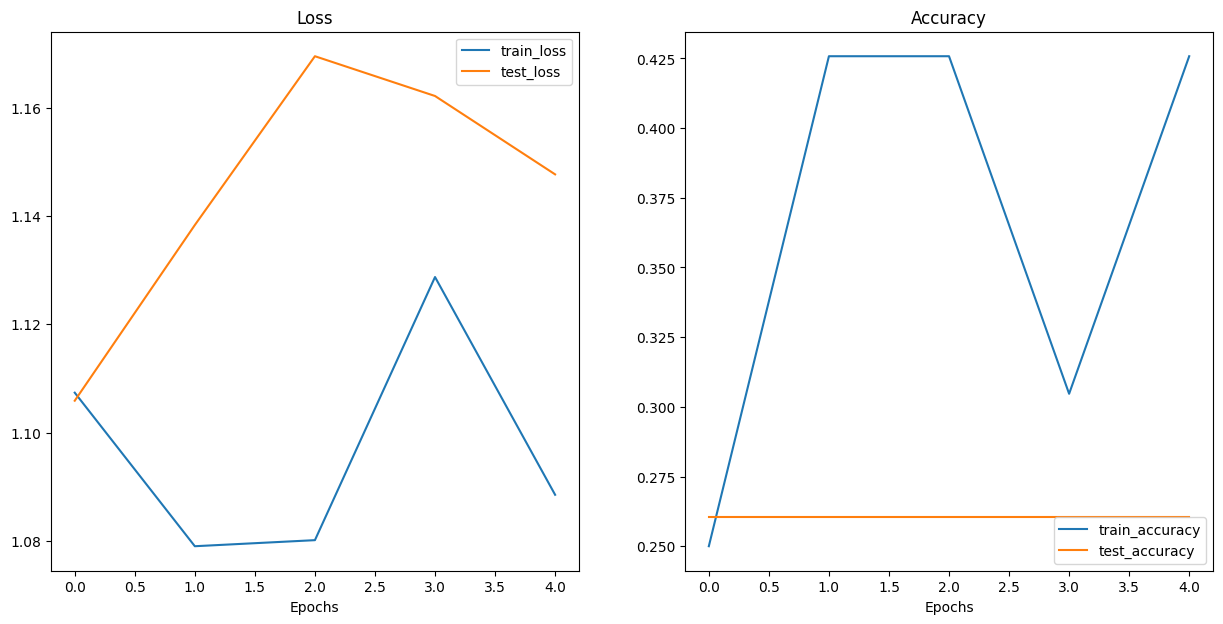

In [64]:
plot_loss_curves(model_1_results)

# 10 ) 모델 결과 비교

In [65]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.107836,0.257812,1.136212,0.260417
1,1.084601,0.425781,1.162302,0.197917
2,1.115460,0.292969,1.169465,0.197917
3,1.098594,0.414062,1.134397,0.197917
4,1.098696,0.292969,1.143336,0.197917


matplotlib을 사용하여 model_0와 model_1의 결과를 한데 모아 시각화하는 그래프 코드 작성

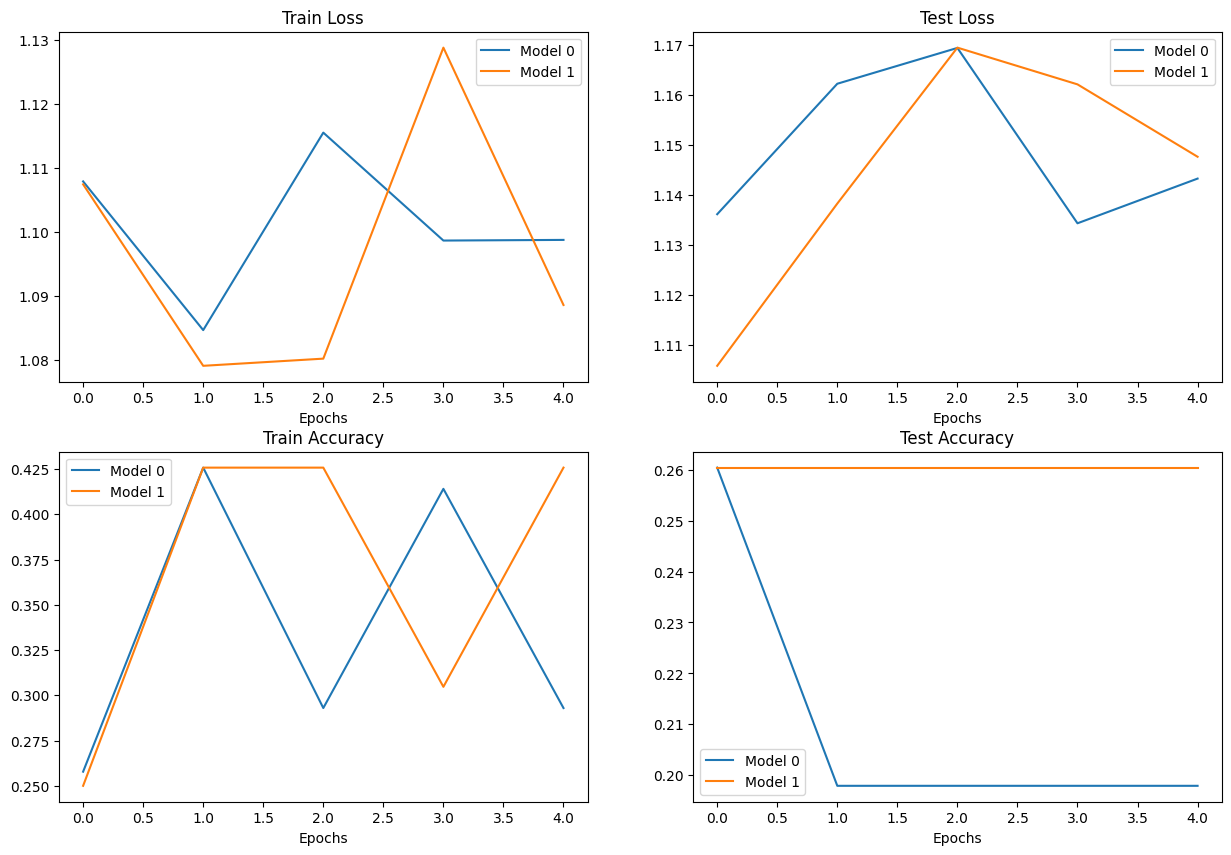

In [66]:
plt.figure(figsize=(15, 10))

epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

# 11) 커스텀 이미지로 예측하기
- 직접 준비한 이미지 중 하나를 모델이 어떻게 예측하는지 확인해보기
-  모델이 훈련받았던 데이터와 형식이 일치하도록 전처리 <br>
1. 우리만의 커스텀 이미지를 텐서(Tensor)로 변환 <br>
2. 모델에 넣기 전에 올바른 데이터 타입인지 확인  <br>

In [67]:
# 커스텀 이미지 다운
import requests

# 커스텀 이미지 경로 설정
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# 11.1 ) 파이토치로 커스텀 이미지 불러오기

파이토치의 torchvision 모듈 - 이미지와 비디오를 읽고 쓰기 위한 여러 가지 입출력(Input/Output, 줄여서 "IO" 또는 "io") 메서드들이 torchvision.io에 포함되어 있음
- 우리는 이미지를 불러오길 원하므로, torchvision.io.read_image()를 사용할 것 <br>
이 메서드는 JPEG 또는 PNG 이미지를 읽어서, 데이터 타입이 uint8이고 값의 범위가 [0, 255] 사이인 3차원 RGB 또는 그레이스케일(흑백) torch.Tensor로 변환해줌

In [68]:
import torchvision

# 커스텀 이미지 읽어오기
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dty

-> <br>
1. Custom image tensor (데이터의 내용)-이미지의 픽셀 값

 가장 바깥쪽 대괄호가 3개 : [빨강, 초록, 파랑] 3개의 색상 층(Channel) <br>

154, 173, 181... 같은 숫자들 :  0(검은색)부터 255(흰색) 사이의 밝기<br>

dtype=torch.uint8: 이건 "부호 없는 8비트 정수"라는 뜻, 메모리를 아끼기 위해 정수 형태로 저장된 상태 (하지만 모델은 소수점이 있는 float32를 선호)<br>

2. Custom image shape: torch.Size([3, 4032, 3024])

3: 컬러 채널 수 (RGB)<br>

4032: 이미지의 높이(Height) 픽셀 수<br>

3024: 이미지의 너비(Width) 픽셀 수<br>

- custom_image 텐서는 torch.uint8 데이터 타입이며 값은 [0, 255] 사이
- 우리 모델은 데이터 타입이 torch.float32이고 값이 [0, 1] 사이인 이미지 텐서를 입력으로 받음
- 커스텀 이미지를 모델이 사용하기 전에, 우리 모델이 학습했던 데이터와 동일한 형식으로 변환해야 함


In [69]:
# 커스텀 이미지 불러오고 텐서 값을 float32으로 변환
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

# 0~255 사이의 값을 0~1 사이로 정규화
custom_image = custom_image / 255. 

print(f"Custom image tensor:\n{custom_image}\n")
print(f"Custom image shape: {custom_image.shape}\n")
print(f"Custom image dtype: {custom_image.dtype}")

Custom image tensor:
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..

*정규화 장점
1. 계산의 안정성 -> 1보다 작은 소수점 숫자들을 곱하면 값이 큰 숫자들에 비해 안정적으로 유지됨
2. 학습 속도 향상 (지름길 찾기) -> 정규화를 하면 모든 데이터의 스케일이 비슷해져서, 모델이 정답을 향해 훨씬 더 곧고 빠르게 내려갈 수 있음
3. 모든 특징(Feature)을 공평하게 대함 -> 정규화를 통해 모든 데이터를 0~1 사이의 동일한 선상에 두어 공평한 학습 가능

# 11.2 ) 훈련된 파이토치 모델로 커스텀 이미지 예측하기

- matplotlib을 사용해 이미지가 괜찮아 보이는지 그려보기
- !! 이때 matplotlib의 요구 사항에 맞춰 차원 순서를 CHW에서 HWC로 변경(permute)해야 한다는 점을 잊지 말기

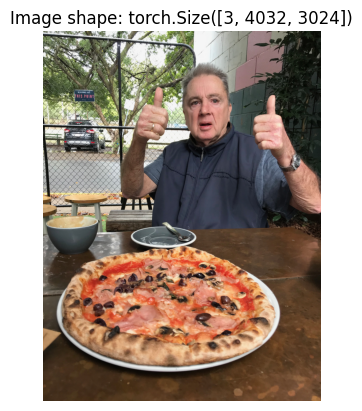

In [70]:
plt.imshow(custom_image.permute(1, 2, 0)) #  permute image dimensions from CHW -> HWC otherwise matplotlib will error
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False);

In [71]:
# Create transform pipleine to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
New shape: torch.Size([3, 64, 64])


In [73]:
model_1.eval()
with torch.inference_mode():
    
    # 이미지에 여분의 차원 추가 
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    
    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")
    
    # 여분의 차원을 가진 이미지로 예측하기
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


 => 우리 모델은 이미지 텐서의 맨 앞에 배치 크기 차원이 포함된 형태(NCHW, 여기서 N은 배치 크기)를 기대함<br>

but 현재 우리의 커스텀 이미지는 오직 CHW 형태<br>

-> torch.unsqueeze(dim=0)를 사용하여 이미지에 여분의 차원을 추가함으로써, 배치를 고려한 예측을 수행할 수 있음<br>

*unsqueeze(dim=0) : 1인 차원 추가. (dim=)을 통해 어느 차원에 1인 차원 생성할지 지정해줘야 함. <br>
squeeze : 차원이 1인 차원 제거

- 딥러닝과 파이토치의 3대 고전적 문제 

1. 잘못된 데이터 타입 (Wrong datatypes)
2. 잘못된 장치 (Wrong device)
3. 잘못된 모양 (Wrong shapes)


In [74]:
# 모델의 예측 확인
custom_image_pred

tensor([[ 0.1182,  0.0275, -0.1456]], device='cuda:0')

In [76]:
print(f"Prediction logits: {custom_image_pred}")

# logits -> 예측 확률 변환(using torch.softmax() for multi-class classification)
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")

Prediction logits: tensor([[ 0.1182,  0.0275, -0.1456]], device='cuda:0')
Prediction probabilities: tensor([[0.3729, 0.3406, 0.2865]], device='cuda:0')
Prediction label: tensor([0], device='cuda:0')


-> 예측 확률값이 클래스 별로 37%, 33%, 27% 밖에 안됨 <br>
=> 모델의 불안감이 느껴짐

In [77]:
custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class

'pizza'

*
1. 모델이 예측을 수행할 때는 이미지와 모델 둘 다 GPU에 있어야 합니다. 그래야 엄청나게 빠른 속도로 행렬 곱셈을 할 수 있음

2. 계산이 끝난 후, 그 결과(0, 1, 2 같은 인덱스)를 가지고 파이썬 리스트(class_names)에서 이름을 찾음
GPU에 있는 것: custom_image_pred_label (계산 결과인 숫자 텐서), <br>
CPU에 있는 것: class_names (파이썬 리스트 ['pizza', ... ])<br>
파이썬의 일반적인 리스트는 GPU에 저장된 데이터를 직접 들여다볼 능력이 없음

3. GPU에서 열심히 계산해서 답을 내놓음 -> 그 답을 우리가 읽을 수 있는 리스트와 매칭하기 위해 GPU 작업실에서 CPU 사무실로 서류(데이터)를 가지고 나오는 과정이 바로 .cpu()

# 11.3 ) 커스텀 이미지 예측 통합 : 함수 만들기

- 예측 확률값이 상당히 비슷함 - 2가지 의미일 수 있음

1. 모델이 세 가지 클래스를 동시에 예측하려 하고 있음 (예: 한 이미지 안에 피자, 스테이크, 스시가 모두 들어있는 경우)

2. 모델이 무엇을 예측해야 할지 정말로 몰라서, 결과적으로 각 클래스에 비슷한 수치를 할당하고 있음 <br>
=> 우리의 경우는 2. 모델이 제대로 훈련되지 않았기 때문에, 기본적으로 예측을 '때려 맞히고(guessing)' 있는 상태

- 함수 제작 단계
이 모든 과정을 하나로 묶어 언제든 쉽게 재사용할 수 있는 함수를 만들기

- 다음과 같은 기능 수행

1. 대상 이미지 경로를 입력받아 모델에 맞는 데이터 타입(torch.float32)으로 변환
2. 이미지 픽셀 값이 [0, 1] 범위에 있는지 확인
3. 필요한 경우 이미지를 변형(Transform)
4. 모델이 대상 장치(Target Device)에 있는지 확인
5. 훈련된 모델로 이미지를 예측 (이미지 크기와 장치가 모델과 일치하는지 확인 포함)
6. 모델의 출력값인 로짓(Logits)을 예측 확률(Prediction Probabilities)로 변환
7. 예측 확률을 예측 라벨(Prediction Labels)로 변환
8. 대상 이미지와 함께 모델의 예측 결과 및 확률을 그래프로 그림(Plot)

In [78]:
def pred_and_plot_image(model: torch.nn.Module, 
                        image_path: str, 
                        class_names: List[str] = None, 
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    
    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    
    # 2. Divide the image pixel values by 255 to get them between [0, 1] - 정규화
    target_image = target_image / 255. 
    
    # 3. Transform if necessary  
    if transform:
        target_image = transform(target_image)
    
    # 4. Make sure the model is on the target device
    model.to(device)
    
    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)
    
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))
        
    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

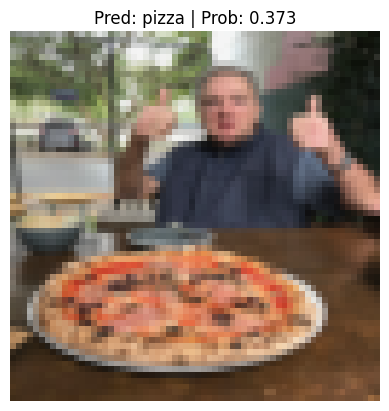

In [79]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

custom_image_transform을 사용하여 이미지 크기를 [64, 64]로 조정했기 때문에 이미지가 많이 깨져(픽셀화되어) 보임

# 핵심 요약
- 다양한 데이터 처리<br>
: 파이토치에는 시각(Vision), 텍스트, 오디오, 추천 시스템 등 모든 종류의 데이터를 다루기 위한 수많은 내장 함수가 있습니다.<br>

- 커스텀 데이터셋<br>
: 파이토치의 내장 데이터 로딩 함수가 요구 사항에 맞지 않는다면, torch.utils.data.Dataset을 상속받아 직접 커스텀 데이터셋을 만드는 코드를 작성할 수 있습니다.<br>

- 데이터로더(DataLoader) <br>
: torch.utils.data.DataLoader는 데이터셋을 모델 학습 및 테스트에 사용할 수 있는 반복 가능한 형태(iterables)로 변환해줍니다.<br>

- 과적합(Overfitting)과 과소적합(Underfitting)<br>
: 머신러닝의 상당 부분은 이 둘 사이의 균형을 맞추는 일<br>

- 커스텀 데이터 예측<br>
: 훈련된 모델로 자신만의 데이터를 예측하는 것은 가능합니다. 단, 데이터를 모델이 학습했을 때와 유사한 형식으로 맞춰야 합니다. <br>
특히 파이토치와 딥러닝의 3대 주요 에러를 주의하세요:<br>

1. 잘못된 데이터 타입: 데이터는 uint8인데 모델은 float32를 기대할 때.<br>

2. 잘못된 데이터 모양: 데이터는 [채널, 높이, 너비]인데 모델은 [배치_크기, 채널, 높이, 너비]를 기대할 때.<br>

3. 잘못된 장치: 모델은 GPU에 있는데 데이터는 CPU에 있을 때.<br>